# Diabetes Risk Factor Analysis


# 1. Purpose and Overview

#### Purpose

This notebooks examines how eight health measurements differ between patients based on diabetes status. Predictor variables include pregnancies, glucose, diastolic blood pressure, skin thickness, insulin, BMI, predigree, and age. The outcome is a binary diabetes status (0 = no diabetes, 1 = has diabetes).

Before the analysis, the data is cleaned, validated, and summarized.

Several measurements have values that are implausible (e.g., BMI < 0 or age > 150) or indicate that missing measurement (e.g., BMI = 0), so these values are set as missing, per the predefined validity rules set in Section 6. In addition, duplicate observations are identified and removed, and data types are checked.

The analysis then proceeds to perform descriptive statistics for each predictor overall and by outcome group, visualization of the distributions between predictors and by outcome, and inferential analysis to identify whether each predictor differs between the two outcome groups.

#### Overview

| Section | Contents |
|---|---|
| 1 | Purpose and Overview |
| 2 | Setup and Environment |
| 3 | Data Source and Provenance |
| 4 | Data Validation and Review |
| 5 | Data Preparation and Cleaning |
| 6 | Analysis |
| 7 | Results |
| 8 | Reproducibility Check |
| 9 | Results and Conclusions |

#### To Run

Open in Google Colab and select `Run all`. The raw dataset is pulled automatically from a public GitHub repository. Alternatively, the dataset can be uploaded to the Google Colab environment and the notebook will detect/use that copy instead (However, this approach is not recommended, as the dataset uploaded manually may differ than the version this notebook was first developed and validated with). The first cell installs required package versions. The cleaned dataset and figures are saved to the /outputs folder in the notebook environment.

## 2. Setup and Environment

This sections contains: package versions, package importing, random seed setting, and input/output file locations.

---

- 2.1. Package Versions - Install the versions this notebooks was built and tested with into the runtime environment.

- 2.2. Import - Import all necessary packages. All packages used throughout the notebook can be found here.

- 2.3. Environment Check - Prints the running Python and package versions. Every line should read as `ok`, indicating the version matches the specified version.

- 2.4. Random Seed - Set a seed for reproducibility. This ensures that the results are identical between runs.

- 2.5. File Paths - Define the input and output file paths used throughout the notebook. Includes local dataset location, url dataset location, cleaned dataset output, and directory for saved figures.

---

Note: Colab runtimes start with whatever package versions Google currently ships, which change over time. Cell 1.1 installs the versions this notebook is built with, and 1.3 confirms they are the ones being used. This applies to external libraries (e.g., pandas, numpy, matplotlib, scipy, seasborn), which can be installed at a specific version. Standard libraries (e.g., os, sys, operator) are bundled with the Python release.

#### 2.1. Package Versions


In [36]:
# Versions this notebook was built and tested with
REQUIRED_PYTHON = "3.13.15"
REQUIRED_VERSIONS = {
    "pandas": "2.2.3",
    "numpy": "2.1.3",
    "matplotlib": "3.10.0",
    "scipy": "1.16.3",
    "seaborn": "0.13.2"

}

# Install required versions into Colab runtime
# Builds "pandas==2.3.3 numpy==2.1.3" from dictionary to pass to the pip install call
# Note: To learn how to install specific package versions to the current runtime:
  # Claude Fable 5. Based on the response to prompt: "How to install specific Python package version to the runtime environment in Google Colab."
packages = " ".join(f"{name}=={version}" for name, version in REQUIRED_VERSIONS.items())
!pip install -q {packages}

#### 2.2. Import


In [37]:
# Standard python libraries
import sys
import platform
from importlib.metadata import version
from operator import lt, le, eq, ge, gt
import os
import urllib.request
from pathlib import Path

# External python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
import seaborn as sns

#### 2.3. Environment Check

In [38]:
# Note: To learn how to check specific package versions in the current environment
  # Claude Fable 5. Based on the response to prompt: "How can I check and verify the current Python package version installed in Google Colab."
# Comapre the running python version against the specified version above
python_running = platform.python_version()
# stats = ok if it matches, print a mismatch statement if not.
status = "ok" if python_running == REQUIRED_PYTHON else f"Mismatch {python_running} version. Installed: {python_running}. Required: {REQUIRED_PYTHON}."
print(f"python {REQUIRED_PYTHON} {status}")

# Comapre each running package version to its specified version above
for name, required in REQUIRED_VERSIONS.items():
  installed = version(name)
  # stats = ok if it matches, print a mismatch statement if not.
  status = "ok" if installed == required else f"Mismatch {name} version. Installed: {installed}. Required: {required}."
  print(f"{name} {required} {status}")

python 3.13.15 ok
pandas 2.2.3 ok
numpy 2.1.3 ok
matplotlib 3.10.0 ok
scipy 1.16.3 ok
seaborn 0.13.2 ok


### 2.4. Random Seed

In [39]:
# Set seed for reproducibility
SEED = 123
rng = np.random.default_rng(SEED)

### 2.5. File Paths

In [40]:
# Lets define the filepaths for the raw dataset
# In Section 4, the local filepath will be checked first (DATA_FILEPATH)
# If local filepath is empty, we will then pull from the GitHub repository (DATA_URL)
# If pulled form the GitHub repository, we will then save to the DATA_FILEPATH for future reference / runs
DATA_FILEPATH = "/content/Example Dataset_Diabetes.csv"
DATA_URL = "https://raw.githubusercontent.com/chaycereed-dartmouth/HSE-751/refs/heads/main/Week%202/data/raw/Example%20Dataset_Diabetes.csv"

# Now, lets define the filepath four our outpus
# First, define the filepath for the cleaned dataset
DATA_FILEPATH_OUTPUT = "/content/outputs/Dataset_Diabetes_Cleaned.csv"
# Next, we define the filepath for the visualizations
FIGURES_FILEPATH_OUTPUT = "/content/outputs/figures"


# 3. Data Source and Provenance


The data source is the Pima Indians Diabetes Dataset, which was originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases. The dataset contains health measurements for 768 female patients and a binary target variable indicating whether each patient has diabetes.

Several measurements record 0 where no reading was taken (glucose, diastolic blood pressure, skin thickness, insulin, and BMI). This is a known characteristic of the dataset (https://search.r-project.org/CRAN/refmans/mlbench/html/PimaIndiansDiabetes.html), and those values are treated as missing in Section 6.

<br>

| Column | Description | Units | Type |
|---|---|---|---|
| `Pregnancies` | Number of times pregnant | count | Integer |
| `Glucose` | Plasma glucose concentration | mg/dL | Integer |
| `D_BP` | Diastolic blood pressure | mmHg | Integer |
| `Skin_Thickness` | Tricep skin fold thickness | mm | Integer |
| `Insulin` | 2-hour serum insulin | mmU/mL | Integer |
| `BMI` | Body Mass Index | kg/m^2 | Float |
| `Pedigree` | Diabetes pedigree function | unitless | Float |
| `Age` | Age | years | Integer |
| `Outcome` | Diabetes Status | 0 = No diabetes, 1 = Has diabetes | Integer |

<br>

#### Acknowledgements

Thanks to the National Institute of Diabetes and Digestive and Kidney Diseases of collecting the original data, Kaggle and the UC Irvine Machine Learning Repository for making it available, and the course for providing the copy used here.

# 4. Data Loading

This sections contains: locating and reading the raw dataset.

---

- 4.1. Reading Dataset - Locate the dataset and read it into the DataFrame.

---

Note: If the dataset was uploaded to the Colab environment, use that copy directly. Otherwise, it is downloaded automatically from the GitHub repository and saved to the local environment for later runs.


4.1. Reading Dataset

In [41]:
# Lets load the raw data that the notebook and analysis depends on
# Note: To learn how to retrieve a dataset from a public repository:
  # Claude Fable 5. Based on the response to prompt: "How can I automatically pull and load a dataset from a public GitHub repository."
# First, lets check if the user already uploaded the dataset
# If so, we can use that directly, and do not need to retrieve the dataset from GitHub
if os.path.exists(DATA_FILEPATH):
  print(f"Data: Using local file: {DATA_FILEPATH}")
# If the dataset does not exist in the current environment,
# lets retrieve it from the GitHub repository, and save it to the environment for future reference
else:
    os.makedirs(os.path.dirname(DATA_FILEPATH), exist_ok = True)
    urllib.request.urlretrieve(DATA_URL, DATA_FILEPATH)
    print(f"Data: Downloaded from {DATA_URL} to {DATA_FILEPATH}")

# Load in the dataset from the local environment
df = pd.read_csv(DATA_FILEPATH)

Data: Using local file: /content/Example Dataset_Diabetes.csv


# 5. Data Validation and Review

This sections contains: defining column groups (predictors and outcomes), data structure, missingness, duplicates, distribution of the outcome, distribution of predictors.

The purpose of this section is to verify the data structure and identify any potential data quality issues before the analysis begins. It organizes the variables into meaningful groups (i.e., predictors and outcome), reviews the datasets dimensions, identifies the column names, data types, and checks for missingness and duplicate rows. This provides an initial review of data completeness and consistency, to help inform the following data preparation and cleaning step.

---

- 5.1. Column Grouping - Group the columns into two types: predictors and outcome. These groups will be referenced throughout the analysis and visualization steps.

- 5.2. Structure - Summarize the column and row counts, column names, column data types, and take a peak at the first 10 rows.

- 5.3. Missing Values - Count the number of missing values per column.

- 5.4. Duplicates - Count the number of duplicate rows.

- 5.5. Save Cleaned Dataset - Save the cleaned dataset to the predefined output location

---

#### 5.1. Column Groups

In [42]:
# Lets include variable-label dictionaries
# This will allow us to easily reference the labels for more readable visualizations
# Predictors
predictors = {
    "Pregnancies": "Pregnancies",
    "Glucose": "Glucose (mg/dL)",
    "D_BP": "Diastolic Blood Pressure (mmHg)",
    "Skin_Thickness": "Skin Thickness (um)",
    "Insulin": "Insulin",
    "BMI": "BMI (kg/m^2)",
    "Pedigree": "Pedigree",
    "Age": "Age (years)"
}

# Outcome
outcome = "Outcome"

#### 5.2. Structure

In [43]:
# Count the number of rows and columns
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 768
Number of Columns: 9


In [44]:
# Summarize the column names and their corresponding data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Pregnancies     768 non-null    int64  
 1   Glucose         768 non-null    int64  
 2   D_BP            768 non-null    int64  
 3   Skin_Thickness  768 non-null    int64  
 4   Insulin         768 non-null    int64  
 5   BMI             768 non-null    float64
 6   Pedigree        768 non-null    float64
 7   Age             768 non-null    int64  
 8   Outcome         768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [45]:
# Lets print the first 10 rows
df.head(10)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


#### 5.3. Missing Values

In [46]:
# Lets create a dataframe to summarize the number of missing values and percent of missing values per column
missing = pd.DataFrame({
    "variable": df.columns,
    "n_missing": df.isna().sum().values,
    "pct_missing": (df.isna().mean() * 100).values
})

# Using .hide() to hide the row numnbers, for cleaner presentation
missing.style.hide(axis = "index").format(precision = 1)

variable,n_missing,pct_missing
Pregnancies,0,0.0
Glucose,0,0.0
D_BP,0,0.0
Skin_Thickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
Pedigree,0,0.0
Age,0,0.0
Outcome,0,0.0


#### 5.4. Duplicates

In [47]:
# Use .duplicated() to determine duplicates, and then .sum() to count the total number of duplicate rows
print(f"Number of Duplcate Values: {df.duplicated().sum()}")

Number of Duplcate Values: 0


# 6. Data Preparation and Cleaning

This sections contains: validity rules, validity check, data type check, and duplicate removal.

The purpose of this section is to prepare the dataset for visualization and analysis by enforcing validity rules, performing consistency checks, and dorpping duplicates. The validity rules identifies values outside plausible ranges and treats them as missing (i.e., sets to NaN), verifies all variables are numeric data types, and removes any duplicate observations.

---

- 6.1. Validity Rules - Define the conditions under which a value is invalid, and therefore treated as missing (i.e., NaN). For example, {le: 0, gt: 150} for Age means that values at or below 0 or above 150 are set to NaN. Outcome values must be 0 or 1.

- 6.2. Data Type Check - Confirm that every column is loaded as a numeric type. All nine columns are numeric by default (7 int64, 2 float64). If a column is not numeric, it is flagged and printed for the user.

- 6.3. Dropping Duplicates - Drop rows that are identical across all columns.

---

#### 6.1. Validity Rules

In [48]:
# Define all validity rules.
# By using the operator functions (e.g., le, gt, eq) we can use and apply these operations directly in our for loop below.
# Note: To learn if how to use operator functions directly (without the need for if/else statement).
  # Claude Fable 5. Based on the response to prompt: "Can I use the comparison symbols directly, instead of the if/elif/else statement?"

# lt = less-than
# le = less-than-or-equal
# eq = equal-to
# gte = greater-than-or-equal
# gt = greater-than

validity_rules = {
    "Age": {le: 0, gt: 150},
    "Glucose": {le: 0},
    "D_BP": {le: 0},
    "Skin_Thickness": {le: 0},
    "Insulin": {le: 0},
    "BMI": {le: 0},
    "Pedigree": {le: 0}
}

outcome_levels = {0, 1}

In [49]:
# Create a clean copy of the df
df_clean = df.copy()

In [50]:
# Note: To learn how to convert my existing for loop into a modular function.
  # Claude Fable 5. Based on the response to prompt: "How can I turn my nested for loop into a modular function. So that I can call the function for each parent loop?"
# Create a modular function for validating and cleaning the data, based on the validity rules defined above
def apply_validity_rules(data, variable, rules):
  """Identify values that violate the validity rules and update to NaN"""
  # First, we extract the rules (operation + threhsold) associated with the variable
  for op, threshold in rules.items():
    # Using the operator library, we can call the operator function defined in the dictionary above
    invalid = op(data[variable], threshold)
    # If the value violates the validity rule, lets print a message to notify the user
    if invalid.any():
        print(f"{variable} {op.__name__} {threshold}: {invalid.sum()} value(s) set to NaN.")
    # Then, lets update the invalid value to nan
    data.loc[invalid, variable] = np.nan

In [51]:
# Predictor validity check
# First, we loop through each variable
for variable, rules in validity_rules.items():
  apply_validity_rules(df_clean, variable, rules)

Glucose le 0: 5 value(s) set to NaN.
D_BP le 0: 35 value(s) set to NaN.
Skin_Thickness le 0: 227 value(s) set to NaN.
Insulin le 0: 374 value(s) set to NaN.
BMI le 0: 11 value(s) set to NaN.


In [52]:
# Outcome validity check
# First, identify any outcome values that are not 0, 1, or NaN
invalid_outcome = -df[outcome].isin(outcome_levels) & df[outcome].notna()
# Check if any invalid outcomes exist
if invalid_outcome.any():
    # If an invalid outcome was identified, lets print a message to the user, before updating it to NaN
    print(f"Invalid Outcome: {invalid_outcome.sum()} value(s) outside {outcome_levels}. Set to NaN.")
    df_clean.loc[invalid_outcome, outcome] = np.nan


In [53]:
# Lets rerun the missingness check, now that we applied our validity rules and addressed the 0 missingness-indicator values
missing = pd.DataFrame({
    "variable": df_clean.columns,
    "n_missing": df_clean.isna().sum().values,
    "pct_missing": (df_clean.isna().mean() * 100).values
})

# Using .hide() to hide the row numnbers, for cleaner presentation
missing.style.hide(axis = "index").format(precision = 1)

variable,n_missing,pct_missing
Pregnancies,0,0.0
Glucose,5,0.7
D_BP,35,4.6
Skin_Thickness,227,29.6
Insulin,374,48.7
BMI,11,1.4
Pedigree,0,0.0
Age,0,0.0
Outcome,0,0.0


#### 6.2. Data Type Check


In [54]:
# Retrieve any non-numeric columns
non_numeric_variables = df_clean.select_dtypes(exclude = "number").columns
# Check if any non-numeric columns exists, if they do, print a statement to notify the user
if not non_numeric_variables.empty:
  print(f"Invaldi Data Type: {len(non_numeric_variables)} column(s) are not numeric:")
  print(df[non_numeric_variables].dtypes.to_string())

#### 6.3. Dropping Duplicates

In [55]:
# Identify and drop any duplicate observations using .drop_duplicates()
df_clean = df_clean.drop_duplicates()

#### 5.5. Save Cleaned Dataset

In [56]:
# First, lets create the output direction, if it doesnt already exist
Path(DATA_FILEPATH_OUTPUT).parent.mkdir(parents = True, exist_ok = True)
# Then, lets save the cleaned dataset to that location
df_clean.to_csv(DATA_FILEPATH_OUTPUT, index = False)

# 7. Analysis

This sections contains: descriptive statistics, visualizations, correlation matrix, and inferential analysis.

---

- 7.1. Descriptive Statistics - Summaries of the cleaned data, including: overall distribution, outcome distribution, predictor distribution, and predictor distribution by outcome group.

  - 7.1.1. Overall Distributions - Mean, standard devation, and quartiles for every column in the dataset.

  - 7.1.2. Outcome Distribution - Count and percentage of patients in each outcome group.

  - 7.1.3 Predictor Distributions - Mean, median, standard deviation, and quartiles for each predictor in the data.

  - 7.1.4. Predictor Distribution by Outcome Group - Mean and standard deviation of each predictor by outcome group.

  - 7.1.5. Mean and Standard Deviation Summary - Explanation and interpretation of means and standard deviation for each predictor.

- 7.2. Visualizations - Visualize the distributions and relationships between predictors and diabetes status.

  - 7.2.1. Predictor Histograms by Diabetes Status - Plot of the distribution of each predictor by diabetes status using overlaid histograms and density curves.

  - 7.2.2. Predictor Boxplots by Diabetes Status - Plot of the distribution of each predictor between diabetes status using boxplots.

  - 7.2.3. BMI vs Glucose Scatter Plot - Plot of BMI vs Glucose to examine the relationship between the two.

  - 7.2.4. Correlation Matrix - Calculated pairwise Spearman rank correlations among the predictor variables to quantify the direction and strength of associations.

  - 7.2.5. Correlation Heatmap - Visualize the Spearman correlation matrix as a heatmap.

- 7.3. Inferential Analysis - Tests whehter predictors differ between patients with and without diabetes.

  - 7.3.1. Student's t-test for glucose - Indepndent two-sample Student's t-test comparing mean glucose between patients with and without diabetes.

  - 7.3.3. Welch's t-tests across all predictors - Welch t-test applied to each of the eight predictors, with Bonferonni-adjusted p-values to account for multiple comparisons.

---

Note: The t-tests assume that each predictor is approximately normally distributed within each group. This assumption may not be met for pregnancies, insulin, and pedigree, which appear to be right skewed. Additionally, the Student's t-test assumes equal variance between groups, which is partially addressed by the accompanying Welch's t-test, which does not rely on that same assumption.

#### 7.1. Descriptive Statistics

##### 7.1.1. Overall Distributions


In [57]:
# Use .describe() to summarize the data (count, mean, sd, quartiles), then .T to transpose it for readability
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
D_BP,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
Skin_Thickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


##### 7.1.2. Outcome Distribution

In [58]:
# Summarize the counts and percent of total counts per outcome group
outcome_counts = df_clean["Outcome"].value_counts().to_frame()
outcome_counts["Percent"] = (outcome_counts / len(df_clean) * 100).round(2)
outcome_counts

,count,Percent
Outcome,,
0,500,65.1
1,268,34.9


##### 7.1.3. Predictor Distributions


In [59]:
# Lets create a table summarizing the distribution for only the predictor variables (drop the outcome variable)
# Then .T for readability
df_clean.drop(columns = "Outcome").describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,763.0,121.686763,30.535641,44.000,99.00000,117.0000,141.00000,199.00
D_BP,733.0,72.405184,12.382158,24.000,64.00000,72.0000,80.00000,122.00
Skin_Thickness,541.0,29.153420,10.476982,7.000,22.00000,29.0000,36.00000,99.00
Insulin,394.0,155.548223,118.775855,14.000,76.25000,125.0000,190.00000,846.00
BMI,757.0,32.457464,6.924988,18.200,27.50000,32.3000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


##### 7.1.4. Predictor Distributions by Outcome Group


In [60]:
# Lets check if the mean and standard deviation of the predictor variables differ by outcome status
# First, groupby() outcome, then aggregate for mean and standard deviation, finally .T for readability
df_clean.groupby("Outcome").agg(["mean", "std"]).T

Outcome                       0           1
Pregnancies    mean    3.298000    4.865672
               std     3.017185    3.741239
Glucose        mean  110.643863  142.319549
               std    24.776906   29.599199
D_BP           mean   70.877339   75.321429
               std    12.161223   12.299866
Skin_Thickness mean   27.235457   33.000000
               std    10.026491   10.327595
Insulin        mean  130.287879  206.846154
               std   102.482237  132.699898
BMI            mean   30.859674   35.406767
               std     6.560737    6.614982
Pedigree       mean    0.429734    0.550500
               std     0.299085    0.372354
Age            mean   31.190000   37.067164
               std    11.667655   10.968254

##### 7.1.5. Mean and Standard Deviation Summary

Each predictor is summarized by its sample mean and standard deviation, computed on the cleaned data (i.e., after applying validity rules and dropping duplicates). The mean describes the typical patient in this cohort, while the standard deviation explains how much patients vary around that expected value.

Mean: $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$

Standard deviation: $s = \sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}$

where:

- $\bar{x}$ = sample mean
- $s$ = sample standard deviation
- $x_i$ = each individual observation
- $n$ = total number of observations

Mean age is 33 years old (SD: 11.8), ranging from 21 to 81 years old, so the cohort is predominantely younger adults. Patients average 3.8 pregnancies (SD: 3.7), ranging from 0 to 17 pregnancies. Mean glucose is 121.7 mg/dL (SD: 30.5), ranging from 44 to 199 mg/dL. Mean diastolic blood pressure is 72.4 mmHg (SD: 12.4), ranging from 24 to 122 mmHg. Mean skin thickness is 29.2 mm (SD: 10.5), ranging from 7 to 99 mm, on the 541 patients with non-missing data for this measurement. Mean insulin is 155.5 mmU/mL (SD: 118.8), ranging from 14 to 846 mmU/mL, on the 394 patients with non-missing data for this measurement. Notably, the SD is close to the mean, and the median (125) is 30 mmU/mL below the mean (155.5), indicating that the measurement is right skewed. Mean BMI is 32.5 kg/m^2 (SD: 6.9), ranging from 18.2 to 67.1, with a median (32.3) that sits closely to the mean (32.5). Mean pedigree is 0.47 (SD: 0.33), ranging from 0.8 to 2.4. Here, the median (0.37) is less than the mean (0.47), indicating a right skew. Standard deviations vary widely across the predictor set, with some being relatively narrow compared to the mean (e.g., BMI) while others are much more spread (e.g., pregnancies).

#### 7.2. Visualizations

##### 7.2.1. Predictor Histograms by Diabetes Status

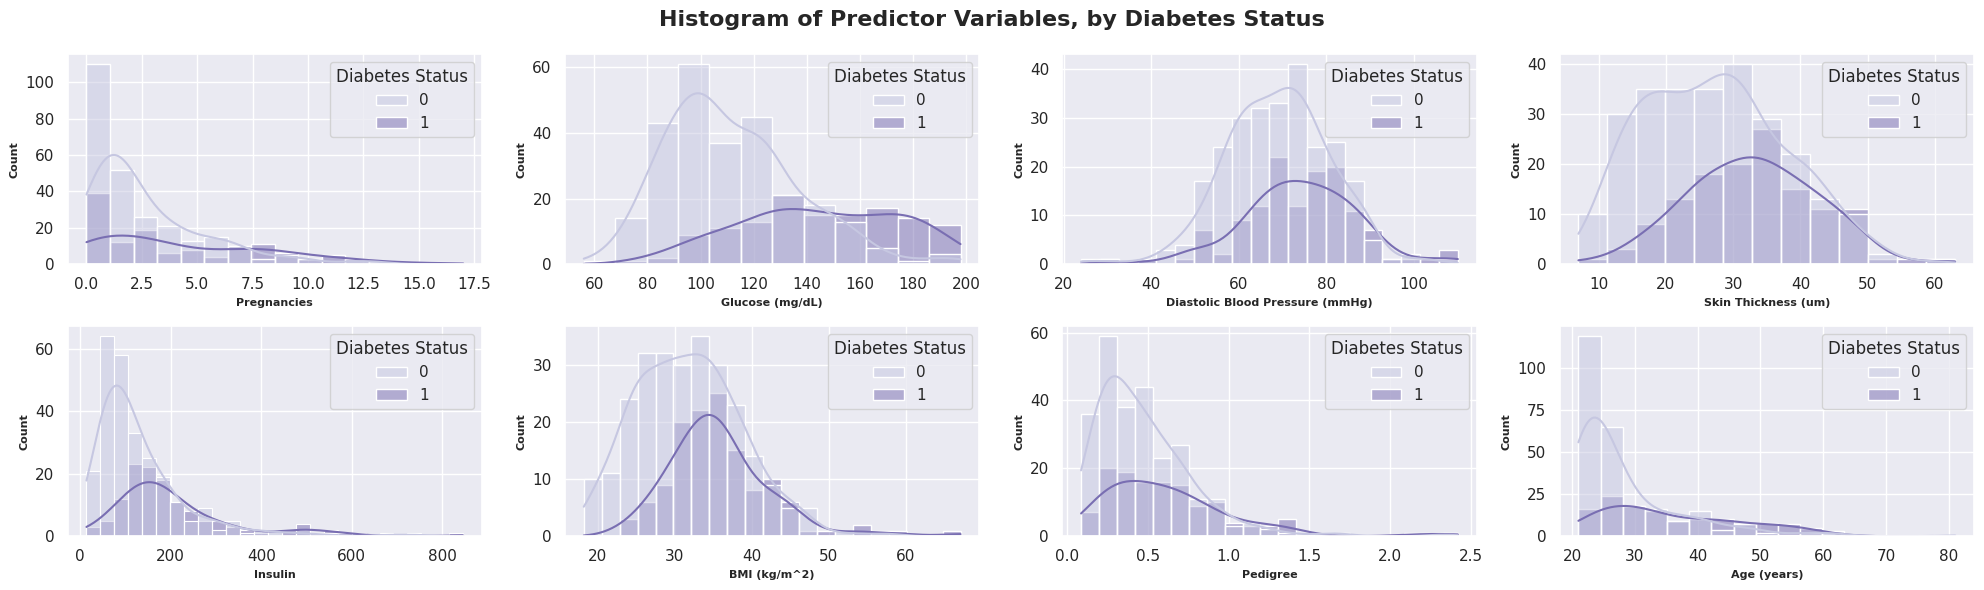

In [61]:
# Since this is the first figure, lets create the directory, if it doesnt already exist
Path(FIGURES_FILEPATH_OUTPUT).mkdir(parents = True, exist_ok = True)

# Lets visualize the distribution of continous variables in our dataset using histograms
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to
# 5 columns, 2 rows
# Note: To learn if how to format the plots into a grid layout, instead of printing them all sequentially.
  # Claude Fable 5. Based on the response to prompt: "Instead of printing my plots sequentially, I want to display them in rows/columns to be more organized."
fig, axes = plt.subplots(2, 4, figsize = (20, 6))

# Loop through each variable, creating the histogram for each
for ax, (variable, label) in zip(axes.flat, predictors.items()):
  # Using kde = True to add the density line, and use ax = ax for the grid layout
  # https://python-graph-gallery.com/20-basic-histogram-seaborn
  sns.histplot(df_clean.dropna(), x = variable, hue = outcome, kde = True, palette = "Purples", alpha = 0.5, ax = ax)
  # Set the corresponding x axis label
  ax.set_xlabel(label, fontsize = 8, fontweight = "bold")
  ax.set_ylabel("Count", fontsize = 8, fontweight = "bold")
  legend = ax.get_legend()
  legend.set_title("Diabetes Status")

# Since we are using a grid layout, lets add one clean title that applies to all plots
# Then, the individual x axis labels can indicate the variable being visualized for each plot
fig.suptitle("Histogram of Predictor Variables, by Diabetes Status", fontsize = 16, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Ensure the grid layout is being applied
fig.tight_layout()
# Save the predictor histogram plots
fig.savefig(f"{FIGURES_FILEPATH_OUTPUT}/predictor_histograms.png")
plt.show()

Each panel overlays the distribution of a predictor for patients without diabetes (light purple) and with diabetes (dark purple). Glucose shows the clearest difference between groups, with the diabetes group shifted right and showing an overall flatter distribution. To a lesser extent, insulin, BMI, and skin thickness also appear to be shifted right for the diabetes group compared to the non-diabetes group. Pregnancies and pedigree, however, follow more similar trends and distributions between both outcome groups. With that said, the non-diabetes group is nearly twice as large, so its bars are generally taller throughout.

##### 7.2.2. Predictor Boxplots by Diabetes Status

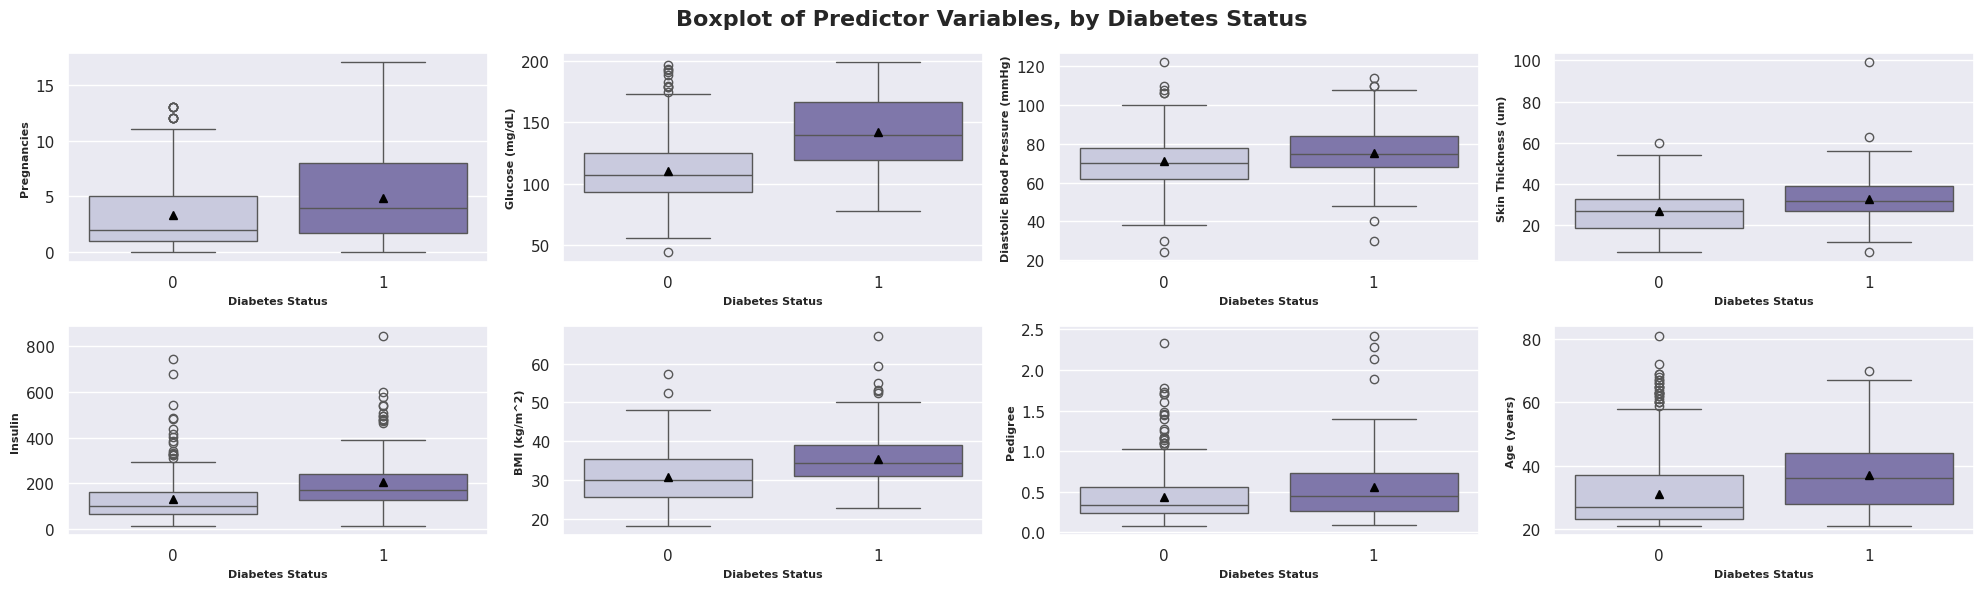

In [62]:
# Instead of printing and displaying each histogram sequentially, lets create a clean grid layout to
# 5 columns, 2 rows
fig, axes = plt.subplots(2, 4, figsize = (20, 6))

# Loop through each variable, creating the boxplot for each
for ax, (variable, label) in zip(axes.flat, predictors.items()):
  # Using hue = outcome to group by diabetes status, and use ax = ax for the grid layout
  # https://python-graph-gallery.com/boxplot
  sns.boxplot(data = df_clean, x = outcome, y = variable, showmeans = True, meanprops = {"markerfacecolor": "black", "markeredgecolor": "black"}, hue = outcome, palette = "Purples", legend = False, ax = ax)
  # Set the corresponding title
  ax.set_xlabel("Diabetes Status", fontsize = 8, fontweight = "bold")
  ax.set_ylabel(label, fontsize = 8, fontweight = "bold")

# Since we are using a grid layout, lets add one clean title that applies to all plots
fig.suptitle("Boxplot of Predictor Variables, by Diabetes Status", fontsize = 16, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Ensure the grid layout is being applied
fig.tight_layout()
# Save the predictor boxplots
fig.savefig(f"{FIGURES_FILEPATH_OUTPUT}/predictor_boxplots.png")
plt.show()

The boxplots confirm the pattern from the histograms, and provides additional insight on how the mean and median values compare between outcome groups. Every predictor's mean and median values are shifted up for the diabetes group, compared to the non-diabetes group. The largest shift appears for the Glucose variable, where the boxes barely overlap and the 1st quartile of the diabetes group is approaching the 3rd quartile of the non-diabetes group. From this perspective, pedigree and diastolic blood pressure appear to be the most consistent, or show the smallest shifts, between the two groups.

##### 7.2.3. BMI vs Glucose Scatter Plot

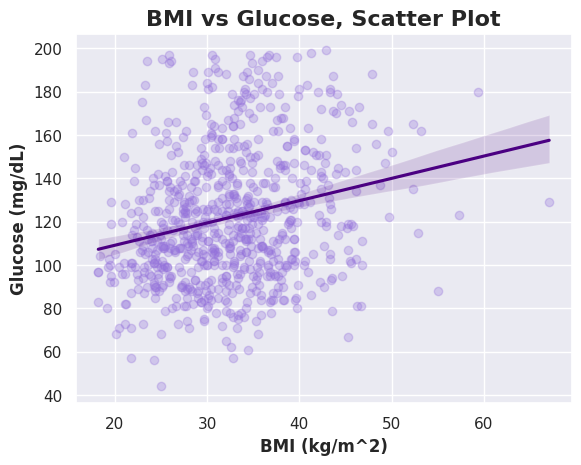

In [63]:
# Now, let's create a scatterplot with a regression line to show the association between BMI and Glucose
# https://python-graph-gallery.com/42-custom-linear-regression-fit-seaborn
sns.regplot(data = df_clean, x = "BMI", y = "Glucose", scatter_kws = {"alpha": 0.3, "color": "mediumpurple"}, line_kws = {"color": "indigo"})
# Set the corresponding x axis label, y axis label, and legend label
plt.xlabel("BMI (kg/m^2)", fontweight = "bold")
plt.ylabel("Glucose (mg/dL)", fontweight = "bold")
# Lets adjust the title to make it bold, and add a secondary title for grouping by study group
# https://python-graph-gallery.com/190-custom-matplotlib-title
plt.title("BMI vs Glucose, Scatter Plot", fontsize = 16, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Save the BMI vs Glucose scatter plot
plt.savefig(f"{FIGURES_FILEPATH_OUTPUT}/bmi_glucose_scatterplot.png")
plt.show()

The scatterplot shows the association between Glucose and BMI for each patient, with a fitted linear regression line demonstrating the general trend across patients. The line slopes upward, indicating that glucose increases alongside BMI. In other words, patients with higher BMI tend to have higher Glucose. However, the points are widely spread and the correlation appears relatively weak.

##### 7.2.4. Correlation Matrix and Heatmap

In [64]:
# Lets create our correlation matrix using .corr(), and rename() to use the readable labels from the predictor dictionary
# Note: To learn how to create a correlation matrix in Python
  # Claude Fable 5. Based on the response to prompt: "How can I make a correlation matrix in Python, how to choose/change the method used, and how to use the values in a dictionary as the labels with the keys as the variables."
# Spearman was chosen over Pearson because Pregnancies, Insulin, Pedigree and Age all appear to be right skewed
correlation_matrix = df[list(predictors)].corr(method = "spearman").rename(index = predictors, columns = predictors)
correlation_matrix.round(2)

,Pregnancies,Glucose (mg/dL),Diastolic Blood Pressure (mmHg),Skin Thickness (um),Insulin,BMI (kg/m^2),Pedigree,Age (years)
Pregnancies,1.00,0.13,0.19,-0.09,-0.13,0.00,-0.04,0.61
Glucose (mg/dL),0.13,1.00,0.24,0.06,0.21,0.23,0.09,0.29
Diastolic Blood Pressure (mmHg),0.19,0.24,1.00,0.13,-0.01,0.29,0.03,0.35
Skin Thickness (um),-0.09,0.06,0.13,1.00,0.54,0.44,0.18,-0.07
Insulin,-0.13,0.21,-0.01,0.54,1.00,0.19,0.22,-0.11
BMI (kg/m^2),0.00,0.23,0.29,0.44,0.19,1.00,0.14,0.13
Pedigree,-0.04,0.09,0.03,0.18,0.22,0.14,1.00,0.04
Age (years),0.61,0.29,0.35,-0.07,-0.11,0.13,0.04,1.00


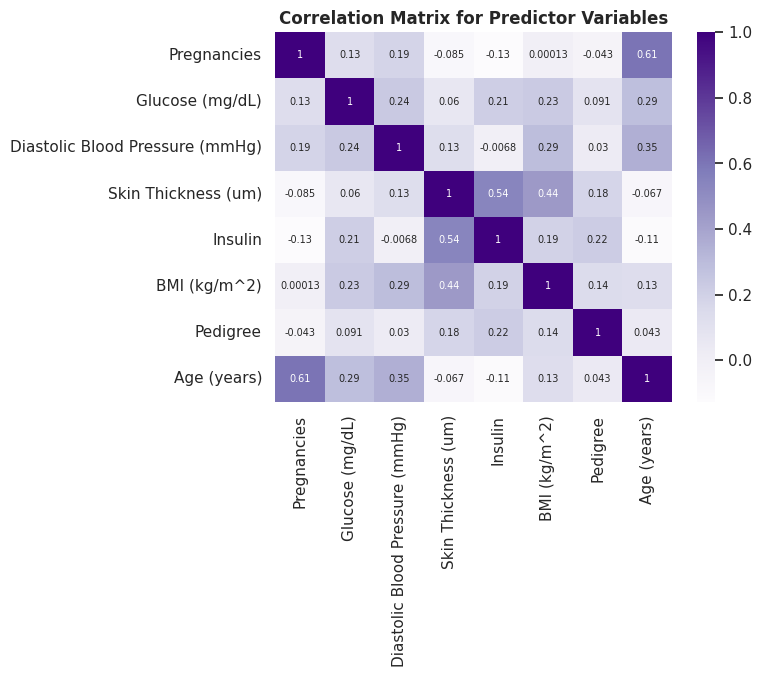

In [65]:
# Create a heatmap to visualize the correlation matrix
# Using annot = True to include the numeric labels
# https://python-graph-gallery.com/91-customize-seaborn-heatmap
sns.heatmap(correlation_matrix, annot = True, annot_kws = {"size": 7}, cmap = "Purples")
plt.title("Correlation Matrix for Predictor Variables", fontsize = 12, fontweight = "bold")
sns.set_theme(style = "darkgrid")
# Save the correlation heatmap
plt.savefig(f"{FIGURES_FILEPATH_OUTPUT}/correlation_heatmap.png", bbox_inches = "tight")
plt.show()

The matrix and heatmap report the Spearman rank correlations between each pair of predictors. Spearman was chosen for it's more robustness to skewed data and outliers, since pregnancies, insulin, pedigree, and age all appear right skewed with outliers.

The strongest relationships were all positive and moderately associated, led by age and pregnancies (0.61), followed by insulin and skin thickness (0.54), and then BMI and skin thickness (0.44). Age is also positively, but weakly, associated with diastolic blood pressure (0.35) and Glucose (0.29). Glucose was positively and weakly associated with diastolic blood pressure (0.24), insulin (0.21), and BMI (0.23). Most remaining pairs fell below 0.2 or were very weakly and negatively associated. Some of these associations are relevant for understanding this dataset because it helps informs whether predictors share information. For example, the relationship between age and pregnancies likely indicate the two explain similar information. Glucose, however, is only weakly associated with the other predictors and so likely contributes information that the rest do not.

#### 7.3. Inferential Analysis

##### 7.3.1 Student's t-test for glucose

In [66]:
# Lets perform an independent 2 sample t-test
# First, lets breakup dataset into two groups: no diabetes and has diabetes, and then subset for Glucose
# Additionally, we need to drop NAs, otherwise we get an NA result
no_diabetes_glucose = df_clean.loc[df_clean["Outcome"] == 0, "Glucose"].dropna()
diabetes_glucose = df_clean.loc[df_clean["Outcome"] == 1, "Glucose"].dropna()

# Perform a two sample t-test using the ttest_ind() to compare the two groups
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
t_stat, p_value = ttest_ind(no_diabetes_glucose, diabetes_glucose)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -15.700907488875874
p-value: 2.4782891993106313e-48


This tests ask whether mean glucose differs between patients with and without diabetes. Based on the descriptive analysis and visualizations, glucose was the predictor that appeared most different between the two groups, making it a strong candidate for this test.

An independent two-sample Student's t-test was used, which compares the group means by dividing their difference by a pooled standard error. It tests the null hypothesis that the two populations have equal mean glucose, under the assumption that that the groups have similar variances.

t-statistic:  $t = \displaystyle\frac{\bar{X}_1 - \bar{X}_0}{s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_0}}}$

Pooled standard deviation: $s_p = \displaystyle\sqrt{\frac{(n_1 - 1)\,s_{X_1}^2 + (n_0 - 1)\,s_{X_0}^2}{n_1 + n_0 - 2}}$

where:
- $\bar{X}_1$, $\bar{X}_0$ = sample mean glucose in the diabetes and no diabetes groups
- $s_{X_1}^2$, $s_{X_0}^2$ = sample variance of glucose in the diabetes and no diabetes groups
- $n_1$, $n_0$ = number of patients in the diabetes and no diabetes groups

The mean glucose is 110.6 mg/dL for the no diabetes group and 142.3 mg/dL for the diabetes group, a difference of 31.7 mg/dL. The test gives t = -15.7 with a p < 0.001, indicating a statistically significant difference in mean glucose between the two groups.

References:

https://en.wikipedia.org/wiki/Student%27s_t-test#Independent_two-sample_t-test

https://medium.com/@snp.kriss/students-t-test-versus-welch-s-t-test-3c129a16b888

Claude Fable 5. Based on the response to prompt: "What is the proper equation for the two-sample t-test and when is it appropriate to use."

##### 7.3.3. Welch's t-test across all predictors

In [67]:
# Create a modular function for comparing predictor means between two groups using Welch's t-test
# Note: To learn how to perform Welchs t-test across all predictors
  # Claude Fable 5. Based on the response to prompt: "Looping through a dictionary with variables as keys and labels as values, how can I perform Welchs t-tet for each of the variables, based on the outcome groups"
def welch_ttest(data, predictors, outcome):
  """Welch two-sample t-test for each predictor between the two groups of outcomes
  data: DataFrame containing predicotrs and outcome
  predictors: dictionary of {column name: display label}
  outcome: binary outcome variable defining the two groups
  Returns a DataFrame with group means, mean difference, 95% CI, p-value, and Bonferroni adjusted p-value
  """
  # First, create a rows list to store the results from each test
  rows = []
  # Loop through each predictor variable
  for variable, label in predictors.items():
    # Create two groups, no diabetes and has diabetes
    no_diabetes = df_clean.loc[df_clean["Outcome"] == 0, variable].dropna()
    diabetes = df_clean.loc[df_clean["Outcome"] == 1, variable].dropna()

    # This time, lets set equal_var = False, to perform Welchs t-test, which does not assume equal population variance
    result = ttest_ind(diabetes, no_diabetes, equal_var = False)
    # Retrieve the confidence intevals for the test
    ci = result.confidence_interval()

    # Creare a dictionary containing variable, mean for each group, difference between means, confidence interval, and p value
    rows.append({
        "Variable": label,
        "Mean (no diabetes)": no_diabetes.mean(),
        "Mean (diabetes)": diabetes.mean(),
        "Difference": diabetes.mean() - no_diabetes.mean(),
        "CI low": ci.low,
        "CI high": ci.high,
        "p": result.pvalue
    })
  # Convert the list to a dataframe
  ttests = pd.DataFrame(rows)
  # Perform bonferroni adjustment to account for multiple comparisons
  ttests["p (Bonferroni)"] = (ttests["p"] * len(predictors)).clip(upper = 1)
  return ttests

In [68]:
# This time, lets perform Welchs t-test for each of the eight predictors
# We will also perform Bonferonni adjustment to account for multiple comparisons.
welch_ttest = welch_ttest(df_clean, predictors, outcome)
welch_ttest

,Variable,Mean (no diabetes),Mean (diabetes),Difference,CI low,CI high,p,p (Bonferroni)
0,Pregnancies,3.298000,4.865672,1.567672,1.046125,2.089219,6.821926e-09,5.457540e-08
1,Glucose (mg/dL),110.643863,142.319549,31.675686,27.493803,35.857568,2.843926e-41,2.275141e-40
2,Diastolic Blood Pressure (mmHg),70.877339,75.321429,4.444090,2.572156,6.316023,3.971545e-06,3.177236e-05
3,Skin Thickness (um),27.235457,33.000000,5.764543,3.928955,7.600131,1.825527e-09,1.460422e-08
4,Insulin,130.287879,206.846154,76.558275,50.460246,102.656305,2.672116e-08,2.137693e-07
5,BMI (kg/m^2),30.859674,35.406767,4.547093,3.560659,5.533527,2.483571e-18,1.986857e-17
6,Pedigree,0.429734,0.550500,0.120766,0.068911,0.172621,6.100481e-06,4.880385e-05
7,Age (years),31.190000,37.067164,5.877164,4.209236,7.545092,1.201513e-11,9.612100e-11


This tests asks which of the eight predictors differ between patients with and without diabetes. Here, Welch's two-sample t-test was used rather than Student's because it does not assume equal population variance between groups.

For each predictor, it tests the null hypothesis that the two populations have equal means, with the Bonferroni adjustment accounting for running the eight tests.

t-statistic: $t = \displaystyle\frac{\bar{X}_1 - \bar{X}_0}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_0^2}{n_0}}}$

Bonferroni adjustment: $p_{\text{adj}} = \displaystyle\min(8p,\, 1)$

where:
- $\bar{X}_1$, $\bar{X}_0$ = sample mean of the predictor in the diabetes and no diabetes groups
- $s_{X_1}^2$, $s_{X_0}^2$ = sample variance of the predictor in the diabetes and no diabetes groups
- $n_1$, $n_0$ = number of patients in the diabetes and no diabetes groups
- $p$ = raw p-value, before Bonferroni adjustment

All eight predictors demonstrated statistically significant differences (Bonferroni-adjusted p < 0.001) between patients with and without diabetes, with each having a higher mean in the diabetes group. The largest differences were demonstrated by insulin. The smallest p-values, and therefore strongest evidence, was found for glucose (Bonferroni-adjusted p = 2.3e-40), followed by BMI (Bonferroni-adjusted p = 2.0e-17) and age (Bonferroni-adjusted p = 9.6e-11).

References:

https://en.wikipedia.org/wiki/Welch%27s_t-test

https://medium.com/@snp.kriss/students-t-test-versus-welch-s-t-test-3c129a16b888

Claude Fable 5. Based on the response to prompt: "What is the proper equation for the Welch's t-test and when is it appropriate to use."

#### 7.4. Data, Statistics, and the Machine Learning Workflow

##### Formalizing the Statistical and Machine Learning Problem

For this analysis, we begin with a dataset consisting of observations (e.g., pregnancies, insulin, BMI, age) and their corresponding target labels. We denote the dataset as:

$$
\mathcal{D} = \{(x_i,y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{p},
\qquad
y_i \in \{0,1\}.
$$

where:

- $\mathcal{D}$ denotes the complete dataset.
- $n$ is the total number of observations (rows) in the dataset, here $n$ = 768.
- $i$ represents the index of an individual observation, where $i = 1,2,\ldots,n$.
- $x_i$ is the feature vector (predictor variables) corresponding to the $i^{th}$ observation.
- $p$ is the total number of predictor (feature) variables, here $p$ = 8.
- $\mathbb{R}^{p}$ denotes the $p$-dimensional real-valued feature space.
- $y_i$ is the target (response) variable associated with observation $i$.
- $\{0,1\}$ indicates that this is a **binary classification** problem, where:
  - $0$ = no diabetes (500 patients, 65.1%).
  - $1$ = diabetes (268 patients, 34.9%).

For the diabetes dataset used in this notebook:

$$
x_i =
\begin{bmatrix}
\text{Pregnancies} \\
\text{Glucose} \\
\text{D_BP} \\
\text{Skin_Thickness} \\
\text{Insulin} \\
\text{BMI} \\
\text{Pedigree} \\
\text{Age}
\end{bmatrix},
\qquad
y_i = \text{Outcome}.
$$

Thus, each observation is represented by a vector of predictor variables, and the machine learning algorithm learns an estimated prediction function:

$$
\hat{f}: \mathbb{R}^{p} \rightarrow \{0,1\},
$$

where:

- $\hat{f}$ (pronounced *"f-hat"*) denotes the **estimated prediction function** learned from the training data.
- The "hat" indicates that the function is an **estimate** of the unknown relationship between the predictor variables and the target variable (i.e., diabetes status).

The function $\hat{f}(\cdot)$ maps an observation's predictor variables to a predicted class label.

The objective of supervised learning is to estimate the function $\hat{f}(\cdot)$ so that it accurately predicts the target variable for observations that were **not** used during model training.

# 8. Reproducibility Check


In [69]:
# A small participant sample used during review
df_clean.sample(8, random_state = SEED)

,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
236,7,181.0,84.0,21.0,192.0,35.9,0.586,51.0,1
395,2,127.0,58.0,24.0,275.0,27.7,1.600,25.0,0
36,11,138.0,76.0,NaN,NaN,33.2,0.420,35.0,0
210,2,81.0,60.0,22.0,NaN,27.7,0.290,25.0,0
483,0,84.0,82.0,31.0,125.0,38.2,0.233,23.0,0
743,9,140.0,94.0,NaN,NaN,32.7,0.734,45.0,1
408,8,197.0,74.0,NaN,NaN,25.9,1.191,39.0,1
468,8,120.0,NaN,NaN,NaN,30.0,0.183,38.0,1


In [70]:
# Bootstrap estimate used during exploratory review
bootstrap_mean_bmi = df_clean["BMI"].sample(n=len(df_clean), replace=True, random_state = SEED).mean()
print("Bootstrap mean BMI:", bootstrap_mean_bmi)

Bootstrap mean BMI: 32.36187335092348


# 9. Results and Conclusions

##### Summary
This notebook examines how various health measurements differ between patients with and without diabetes using the Pima Indians Diabetes dataset. The dataset contains observations for 768 female patients and includes eight health measurements (pregnancies, glucose, diastolic blood pressure, insulin, BMI, pedigree, age) and one outcome variable (diabetes status).

The dataset was loaded, inspected, validated, cleaned, saved, and then desribed using summary statistics, visualizations, and tested using Student's t-test on glucose and Welch's t-test across all eight predictors.

##### Key Findings

Approximately 35% of patients in the dataset had diabetes. All eight predictors differed between the two groups (diabetes and no diabetes) after adjusting for multiple tests via Bonferroni adjustment (Bonferroni adjusted p < 0.001 for every predictor), with the diabetes group having a higher mean across all predictors. Glucose showed the clearest separation (110.6 vs 142.3 mg/dL), followed by BMI (30.9 vs 35.4 kg/m^2) and age (31.2 vs 37.1 years). Based on the correlation matrix, the predictors were moderately-to-weakly correlated with each other, with the strongest pairs being age and pregnancies (0.61), insulin and skin thickness (0.54), and BMI and skin thickness (0.41).

##### Assumptions and Limitations

A key limitation of this analysis was missingness. In the dataset, several measurements contained zeros where it would be physiologically implausible (e.g., BMI = 0), indicating that the measurement was not taken. Insulin and skin thickness columns were most impacted, with 374 and 227 zero values, respectively. These zero values were identified and set to NaN during the data validation, preparation, and cleaning steps. However, during inferential analysis, these missing values were then dropped, reducing the sample size for these predictors and limiting the reliability of their results. Additionally, the reason for missingness is unknown. It is entirely possible that this missingness is systematic rather than random, where patients with recorded values may differ from those without, potentially biasing the results. Additionally, the values for pregnancies, insulin, and pedigree appear to be right skewed, which the t-tests are not fully robust to. A future direction may be to perform Mann-Whitney U or another non-parametric test as an additional robustness check of findings. Finally, the cohort is consisted exclusively of female patients aged 21 and over, which may limit the generalizability of findings to the broader population.

##### Reproducibility

Package versions were specified and installed in the first cell, with a version check that flags any mismatches. A single random seed is set for all random operations to ensure reprodubility of results. Additionally, the notebook detects if a dataset was already uploaded to the environment, and if not, automatically pulls the dataset from a public GitHub repository and then saves it for future use. Cleaning rules are stored as dictionaries rather than independently written lines of code. Additionally, a modular function apply_validity_rules() was created to easily apply the same validation logic to each new predictor. Finally, file paths, column groups, and display labels are defined once and used throughout, enabling easy updates and adjustments, if needed.